<a href="https://colab.research.google.com/github/Ruhul73/House-price-prediction-/blob/main/house_price_data_set_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow_decision_forests as tfdf

In [ ]:
import pandas as pd

###  load file

In [ ]:
df=pd.read_csv("/content/house_prices.csv")

In [ ]:
df

,Unnamed: 0,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,0,Flat,10000000,G-10,Islamabad,2,For Sale,2,4.0
1,1,Flat,6900000,E-11,Islamabad,3,For Sale,3,5.6
2,2,House,16500000,G-15,Islamabad,6,For Sale,5,8.0
3,3,House,43500000,Bani Gala,Islamabad,4,For Sale,4,40.0
4,4,House,7000000,DHA Defence,Islamabad,3,For Sale,3,8.0
...,...,...,...,...,...,...,...,...,...
99494,168435,Flat,7500000,Bahria Town Karachi,Karachi,3,For Sale,3,8.0
99495,168436,House,8800000,Bahria Town Karachi,Karachi,4,For Sale,3,8.0
99496,168438,House,14000000,Bahria Town Karachi,Karachi,3,For Sale,3,8.0
99497,168439,House,14000000,Bahria Town Karachi,Karachi,4,For Sale,4,14.0


In [ ]:
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import classification_report,ConfusionMatrixDisplay

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99499 entries, 0 to 99498
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     99499 non-null  int64  
 1   property_type  99499 non-null  object 
 2   price          99499 non-null  int64  
 3   location       99499 non-null  object 
 4   city           99499 non-null  object 
 5   baths          99499 non-null  int64  
 6   purpose        99499 non-null  object 
 7   bedrooms       99499 non-null  int64  
 8   Area_in_Marla  99499 non-null  float64
dtypes: float64(1), int64(4), object(4)
memory usage: 6.8+ MB


In [ ]:
df=df.drop(['Unnamed: 0'],axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99499 entries, 0 to 99498
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  99499 non-null  object 
 1   price          99499 non-null  int64  
 2   location       99499 non-null  object 
 3   city           99499 non-null  object 
 4   baths          99499 non-null  int64  
 5   purpose        99499 non-null  object 
 6   bedrooms       99499 non-null  int64  
 7   Area_in_Marla  99499 non-null  float64
dtypes: float64(1), int64(3), object(4)
memory usage: 6.1+ MB


In [ ]:
df["property_type"].value_counts()

,count
property_type,
House,58169
Flat,26658
Upper Portion,8539
Lower Portion,5549
Penthouse,255
Room,241
Farm House,88


In [ ]:
df["property_type"]=df["property_type"].replace({"House":0,"Flat":1,"Upper Portion":2,"Lower Portion":3,"Penthouse":4,"Room":5,"Farm House":6})

In [ ]:
df["city"].value_counts()

,count
city,
Karachi,37066
Lahore,26221
Islamabad,22243
Rawalpindi,11738
Faisalabad,2231


In [ ]:
df["city"]=df["city"].replace({"Karachi":0,"Lahore":1,"Islamabad":2,"Rawalpindi":3,"Faisalabad":4})

###  convert catagorical data into numaric value

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder=LabelEncoder()

In [ ]:
df["location"]=encoder.fit_transform(df["location"])

In [ ]:
df["purpose"]=encoder.fit_transform(df["purpose"])

In [ ]:
df.head()

,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,1,10000000,452,2,2,1,2,4.0
1,1,6900000,382,2,3,1,3,5.6
2,0,16500000,457,2,6,1,5,8.0
3,0,43500000,198,2,4,1,4,40.0
4,0,7000000,327,2,3,1,3,8.0


###  partition of data

In [ ]:
y=df["price"]
x=df.drop("price",axis=1)

In [ ]:
x

,property_type,location,city,baths,purpose,bedrooms,Area_in_Marla
0,1,452,2,2,1,2,4.0
1,1,382,2,3,1,3,5.6
2,0,457,2,6,1,5,8.0
3,0,198,2,4,1,4,40.0
4,0,327,2,3,1,3,8.0
...,...,...,...,...,...,...,...
99494,1,189,0,3,1,3,8.0
99495,0,189,0,4,1,3,8.0
99496,0,189,0,3,1,3,8.0
99497,0,189,0,4,1,4,14.0


In [ ]:
df

,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,1,10000000,452,2,2,1,2,4.0
1,1,6900000,382,2,3,1,3,5.6
2,0,16500000,457,2,6,1,5,8.0
3,0,43500000,198,2,4,1,4,40.0
4,0,7000000,327,2,3,1,3,8.0
...,...,...,...,...,...,...,...,...
99494,1,7500000,189,0,3,1,3,8.0
99495,0,8800000,189,0,4,1,3,8.0
99496,0,14000000,189,0,3,1,3,8.0
99497,0,14000000,189,0,4,1,4,14.0


In [ ]:
y

,price
0,10000000
1,6900000
2,16500000
3,43500000
4,7000000
...,...
99494,7500000
99495,8800000
99496,14000000
99497,14000000


###  training the modle

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [ ]:
df.info

<bound method DataFrame.info of        property_type     price  location  city  baths  purpose  bedrooms  \
0                  1  10000000       452     2      2        1         2   
1                  1   6900000       382     2      3        1         3   
2                  0  16500000       457     2      6        1         5   
3                  0  43500000       198     2      4        1         4   
4                  0   7000000       327     2      3        1         3   
...              ...       ...       ...   ...    ...      ...       ...   
99494              1   7500000       189     0      3        1         3   
99495              0   8800000       189     0      4        1         3   
99496              0  14000000       189     0      3        1         3   
99497              0  14000000       189     0      4        1         4   
99498              0   9000000       189     0      3        1         3   

       Area_in_Marla  
0                4.0  
1                5.6  
2                8.0  
3               40.0  
4                8.0  
...              ...  
99494            8.0  
99495            8.0  
99496            8.0  
99497           14.0  
99498            9.4  

[99499 rows x 8 columns]>

In [ ]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69649 entries, 89736 to 2987
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  69649 non-null  int64  
 1   location       69649 non-null  int64  
 2   city           69649 non-null  int64  
 3   baths          69649 non-null  int64  
 4   purpose        69649 non-null  int64  
 5   bedrooms       69649 non-null  int64  
 6   Area_in_Marla  69649 non-null  float64
dtypes: float64(1), int64(6)
memory usage: 4.3 MB


In [ ]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29850 entries, 60905 to 55487
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   property_type  29850 non-null  int64  
 1   location       29850 non-null  int64  
 2   city           29850 non-null  int64  
 3   baths          29850 non-null  int64  
 4   purpose        29850 non-null  int64  
 5   bedrooms       29850 non-null  int64  
 6   Area_in_Marla  29850 non-null  float64
dtypes: float64(1), int64(6)
memory usage: 1.8 MB


###  linearRegression module

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model=LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
df.head()

,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,1,10000000,452,2,2,1,2,4.0
1,1,6900000,382,2,3,1,3,5.6
2,0,16500000,457,2,6,1,5,8.0
3,0,43500000,198,2,4,1,4,40.0
4,0,7000000,327,2,3,1,3,8.0


###  predict the data

In [ ]:
model.predict([[0,23,1,3,1,2,7]])

array([12356734.12262581])

In [ ]:
y_pred=model.predict(x_test)

###  Mean_absolute_error

In [ ]:
from sklearn.metrics import mean_absolute_error

In [ ]:
mean_absolute_error(y_pred,y_test)

5111385.475180475

###  # KNN Classifier

In [ ]:
# KNN Classifier
from sklearn.neighbors import KNeighborsClassifier
data=KNeighborsClassifier(n_neighbors=1)
data.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [ ]:
# Predict and evaluate
model.predict([[0,23,1,3,1,2,7]])

array([12356734.12262581])

In [ ]:
y_pred=model.predict(x_test)

In [ ]:
y_pred

array([14565998.44343526, -6926243.1025885 , 12529183.94986873, ...,
        8898925.88769932, 13850128.10895566, 13123277.01124356])

In [ ]:
df

,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,1,10000000,452,2,2,1,2,4.0
1,1,6900000,382,2,3,1,3,5.6
2,0,16500000,457,2,6,1,5,8.0
3,0,43500000,198,2,4,1,4,40.0
4,0,7000000,327,2,3,1,3,8.0
...,...,...,...,...,...,...,...,...
99494,1,7500000,189,0,3,1,3,8.0
99495,0,8800000,189,0,4,1,3,8.0
99496,0,14000000,189,0,3,1,3,8.0
99497,0,14000000,189,0,4,1,4,14.0


###  graph

In [ ]:
import matplotlib.pyplot as plt

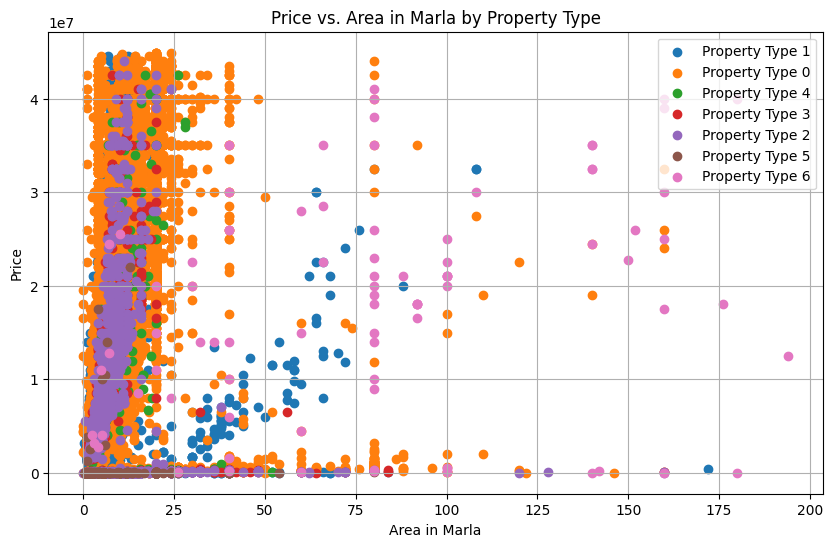

In [ ]:
plt.figure(figsize=(10, 6))
for property_type in df['property_type'].unique():
    subset = df[df['property_type'] == property_type]
    plt.scatter(subset['Area_in_Marla'], subset['price'],label=f'Property Type {property_type}')

plt.title('Price vs. Area in Marla by Property Type')
plt.xlabel('Area in Marla')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import seaborn as sns

<Axes: xlabel='Area_in_Marla', ylabel='price'>

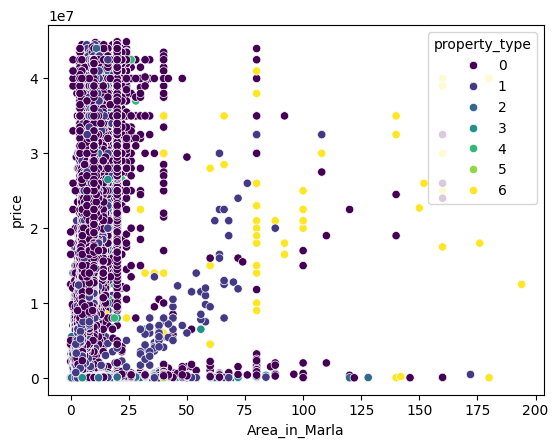

In [ ]:
# Create the scatter plot

sns.scatterplot(data=df, x='Area_in_Marla', y='price', hue='property_type', palette='viridis')

###  DecisionTreeClassifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [ ]:
clf = DecisionTreeClassifier()
clf.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
y_pred = clf.predict(x_test)
y_pred

array([22000000,    45000, 11000000, ...,  6000000, 20000000,  7500000])

### accuracy

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.1323283082077052
